In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt

In [2]:
data = pd.read_csv('/content/combined_data_clean.csv')

In [3]:
print("Checking for Null values:")
print(data.isnull().sum())

Checking for Null values:
FTHG      0
FTAG      0
FTR       0
HTHG      0
HTAG      0
HST       0
AST       0
B365H     0
B365A     0
BWH       0
BWA       0
PSH       0
PSA       0
WHH       0
WHA       0
MaxH      0
MaxA      0
AvgH      0
AvgA      0
AHh       0
B365CH    0
B365CA    0
BWCH      0
PSCH      0
PSCA      0
WHCH      0
MaxCH     0
MaxCA     0
AvgCH     0
AvgCA     0
AHCh      0
IWH       0
IWA       0
VCH       0
VCA       0
dtype: int64


In [4]:
data = data.dropna()

In [5]:
features = ['HTHG', 'HTAG', 'HST', 'AST', 'AvgH', 'AvgA']
X = data[features]
Y = data['FTR'] # Full Time Result (Target)

In [6]:
Xtrain, Xval, Ytrain, Yval = train_test_split(X, Y, test_size=0.2, stratify=Y, random_state=42)

In [7]:
Xtrain.head()

,HTHG,HTAG,HST,AST,AvgH,AvgA
1088,-0.787181,0.715283,2.140331,-0.764263,-0.790954,0.754565
1204,0.410169,-0.691476,0.139446,-0.299702,-1.043894,2.821293
1220,0.410169,0.715283,0.939800,0.629421,0.351638,-0.610652
1998,0.410169,-0.691476,-1.061085,0.164860,-0.729899,0.754565
2096,1.607519,-0.691476,0.539623,-0.764263,-0.869452,1.565293


In [8]:
Ytrain.head()

,FTR
1088,0
1204,2
1220,2
1998,1
2096,2


In [9]:
DTC = DecisionTreeClassifier(criterion="entropy", max_depth=7, random_state=42)
DTC.fit(Xtrain, Ytrain)

DecisionTreeClassifier(criterion='entropy', max_depth=7, random_state=42)

              precision    recall  f1-score   support

           0       0.61      0.73      0.67       221
           1       0.51      0.23      0.32       205
           2       0.69      0.82      0.75       347

    accuracy                           0.64       773
   macro avg       0.60      0.59      0.58       773
weighted avg       0.62      0.64      0.61       773



Text(50.722222222222214, 0.5, 'Actual')

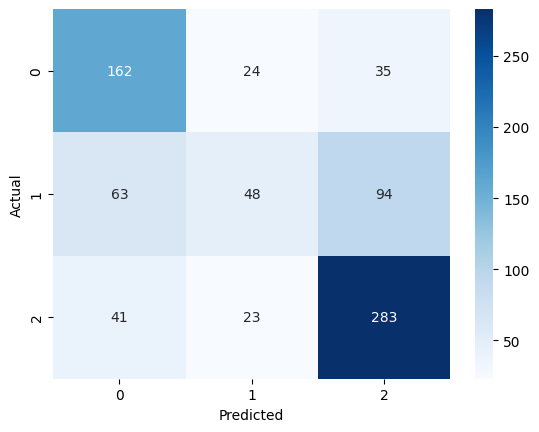

In [19]:
y_test_predict = DTC.predict(Xval)
print(classification_report(Yval, y_test_predict))

# Confusion Matrix to see where the model is getting confused
cm = confusion_matrix(Yval, y_test_predict)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')

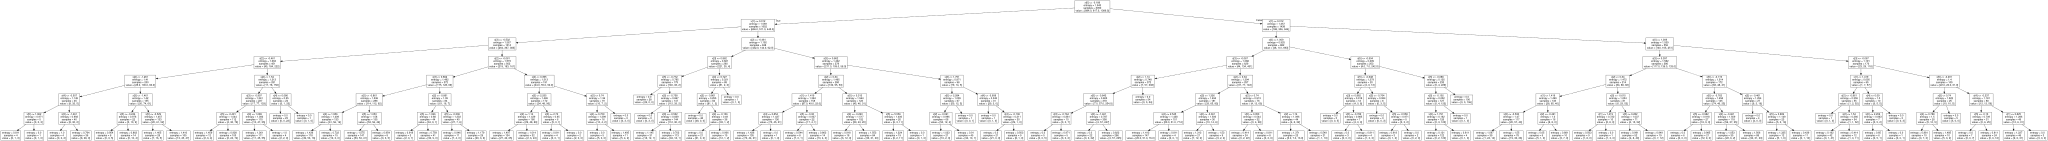

In [14]:
import graphviz
from sklearn import tree
dot_data=tree.export_graphviz(DTC)
graph = graphviz.Source(dot_data, format="png")
graph

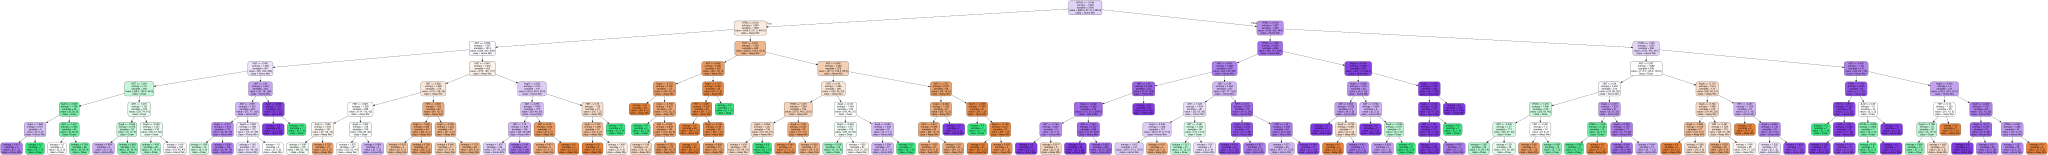

In [15]:
dot_data = tree.export_graphviz(
    DTC,
    out_file=None,
    feature_names=features,           # Shows 'HST' instead of 'x[2]'
    class_names=['Away Win', 'Draw', 'Home Win'], # Adjust based on your FTR encoding
    filled=True,
    rounded=True
)
graph = graphviz.Source(dot_data)
graph

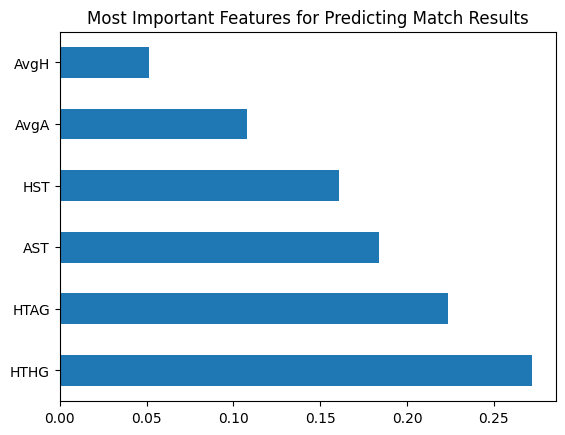

In [16]:
importances = DTC.feature_importances_
feat_importances = pd.Series(importances, index=features)
feat_importances.nlargest(6).plot(kind='barh')
plt.title("Most Important Features for Predicting Match Results")
plt.show()

In [17]:
y_train_predict = DTC.predict(Xtrain)
y_test_predict = DTC.predict(Xval)

train_acc = accuracy_score(Ytrain, y_train_predict)
test_acc = accuracy_score(Yval, y_test_predict)

print(f"\nTraining Accuracy: {train_acc:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")


Training Accuracy: 0.6761
Test Accuracy: 0.6378


In [18]:
if train_acc > test_acc + 0.1:
    print("Comment: The model might be slightly overfitting as training accuracy is significantly higher.")
else:
    print("Comment: The model generalizes well as train and test accuracies are close.")

Comment: The model generalizes well as train and test accuracies are close.
